# Diversity picking

Let's pick a representative set of 100 molecules that are as diverse as possible.

In [1]:
import pandas as pd
from numpy.ma.extras import column_stack

df = pd.read_csv('../my_data/structures_best.csv', usecols=['Canonical_SMILES', 'Source'])

In [2]:
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker

# 1. Initialize the Generator
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# 2. Generate Fingerprint objects directly from SMILES
# We create a temporary list to avoid index mismatching if some SMILES fail
df = df.dropna(subset=['Canonical_SMILES']).copy()

def get_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return fp_gen.GetFingerprint(mol) if mol else None

df['fp_object'] = df['Canonical_SMILES'].apply(get_fp)

# Drop any rows where SMILES couldn't be parsed
df = df.dropna(subset=['fp_object']).copy()

# 3. Setup the MaxMin Picker
fps = df['fp_object'].tolist()
n_to_pick = 100
picker = MaxMinPicker()

# Tanimoto distance function
def dist_func(i, j, fps=fps):
    return 1 - DataStructs.TanimotoSimilarity(fps[i], fps[j])

# 4. Run the picking algorithm
# This picks indices relative to the 'fps' list
picked_indices = picker.LazyPick(dist_func, len(fps), n_to_pick, seed=42)

# 5. Mark the picked molecules in the dataframe
df['Picked'] = False
# Using iloc to match the list position of the picked indices
df.iloc[list(picked_indices), df.columns.get_loc('Picked')] = True

print(f"Total molecules processed: {len(df)}")
print(f"Molecules selected for diversity: {df['Picked'].sum()}")

Total molecules processed: 18896
Molecules selected for diversity: 100


Let's see what the picked molecules look like:

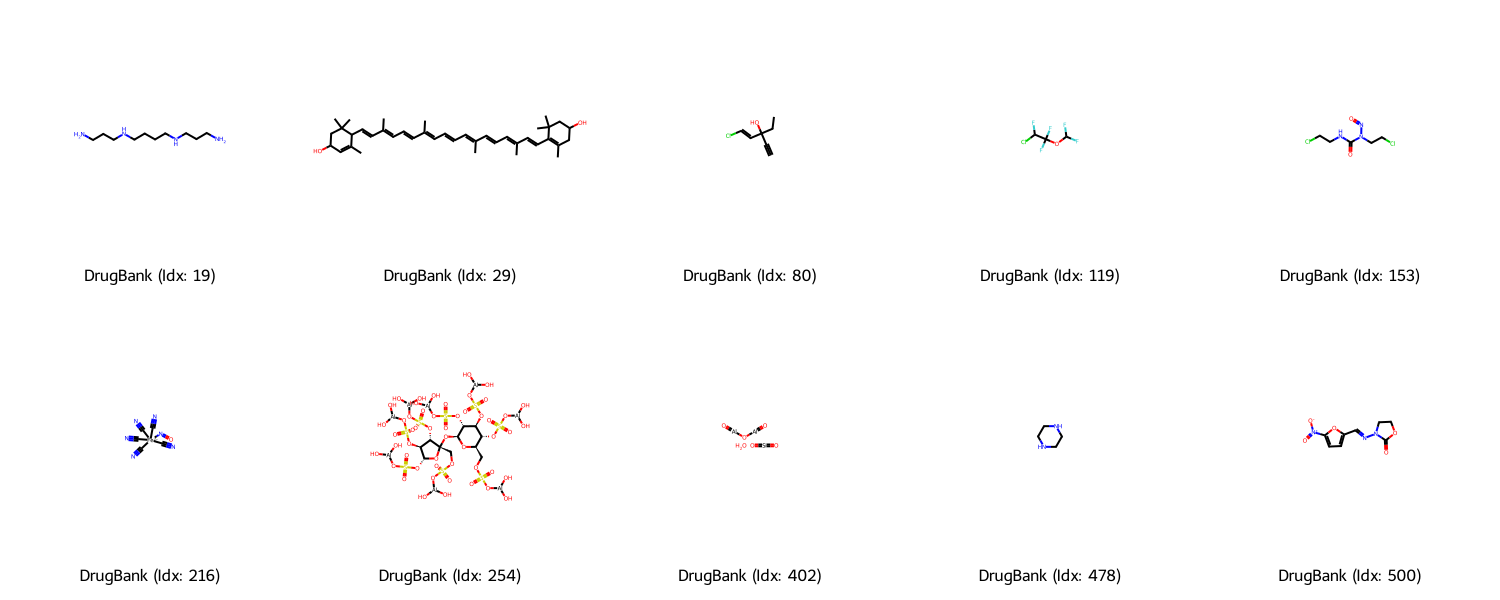

In [3]:
from rdkit import Chem
from rdkit.Chem import Draw

# 1. Filter the dataframe for only the picked molecules
picked_df = df[df['Picked']].head(10)

# 2. Create molecule objects for drawing
mols_to_draw = [Chem.MolFromSmiles(s) for s in picked_df['Canonical_SMILES']]

# 3. Create legends (using Source and an index for clarity)
legends = [f"{row['Source']} (Idx: {i})" for i, row in picked_df.iterrows()]

# 4. Generate the grid image
img = Draw.MolsToGridImage(
    mols_to_draw,
    molsPerRow=5,
    subImgSize=(300, 300),
    legends=legends
)

# Display the image
display(img)

We can see that it takes mostly from Drugbank.

In [4]:
df.columns

Index(['Canonical_SMILES', 'Source', 'fp_object', 'Picked'], dtype='str')

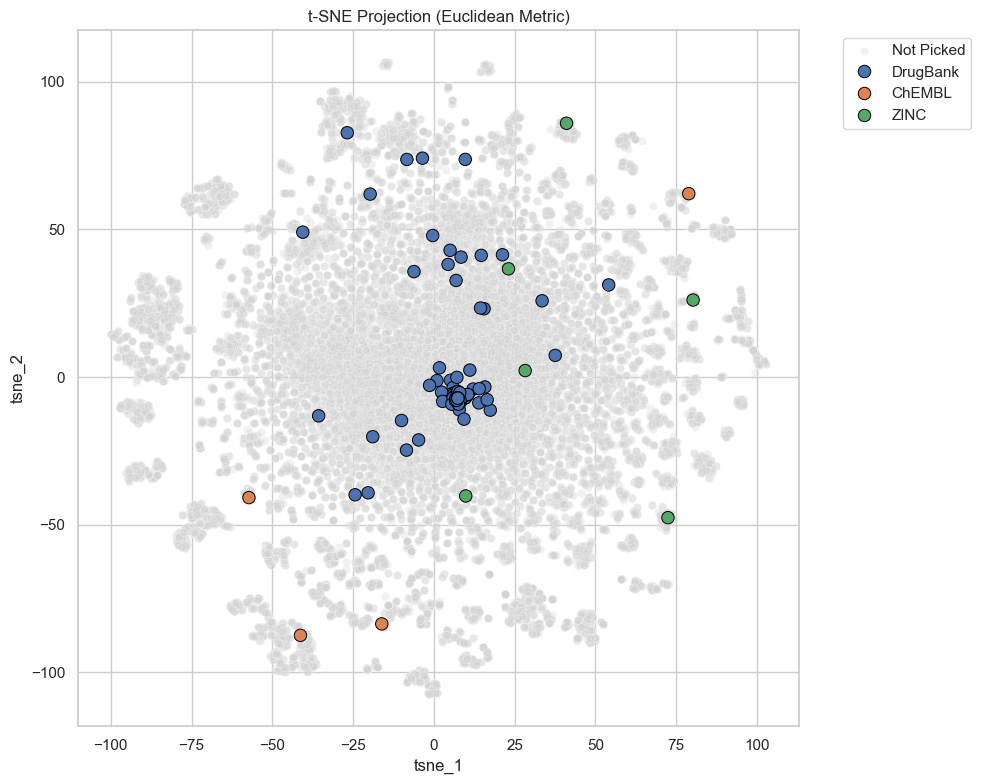

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
sns.set_theme(style="whitegrid")

# 1. Convert fp_objects to a 2D numpy array
X = np.array([list(fp) for fp in df['fp_object']])

# 2. Run t-SNE with Euclidean metric
tsne = TSNE(
    n_components=2,
    metric='euclidean',
    init='pca',         # PCA works well with Euclidean distance
    learning_rate='auto',
    random_state=42,
    n_jobs=-1
)
X_embedded = tsne.fit_transform(X)

# 3. Update coordinates in the dataframe
df['tsne_1'] = X_embedded[:, 0]
df['tsne_2'] = X_embedded[:, 1]

# 4. Visualize
plt.figure(figsize=(10, 8))
# Background
sns.scatterplot(
    data=df[~df['Picked']],
    x='tsne_1', y='tsne_2',
    color='lightgrey', alpha=0.3, label='Not Picked'
)
# Picked molecules
sns.scatterplot(
    data=df[df['Picked']],
    x='tsne_1', y='tsne_2',
    hue='Source', s=80, edgecolor='black', alpha=1.0
)

plt.title("t-SNE Projection (Euclidean Metric)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

This is not that diverse I would expect but thats probably due to a different metric (we use eucleideidien instead of jaccard in tsne). Jaccard takes too long.